# AprioriTid Algorithm
Model untuk Frequent Pattern Mining dengan Transaction ID encoding

## Cell 1: Import Libraries & AprioriTid Implementation

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

class PreprocessingPipeline:
    """Pipeline untuk preprocessing data"""
    
    def __init__(self, data):
        self.data = data.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
    
    def handle_missing_values(self):
        """Handle missing values"""
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.data[numeric_cols] = self.imputer.fit_transform(self.data[numeric_cols])
        
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            self.data[col].fillna(self.data[col].mode()[0] if len(self.data[col].mode()) > 0 else 'Unknown', inplace=True)
        
        print("✓ Handle Missing Values: Selesai")
        return self
    
    def handle_outliers(self):
        """Handle outliers dengan IQR method"""
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        
        for col in numeric_cols:
            Q1 = self.data[col].quantile(0.25)
            Q3 = self.data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            mask = (self.data[col] >= lower_bound) & (self.data[col] <= upper_bound)
            outlier_count += (~mask).sum()
            self.data = self.data[mask]
        
        print(f"✓ Handle Outliers: Dihapus {outlier_count} data outlier")
        return self
    
    def label_encoding(self):
        """Label encoding untuk categorical features"""
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        
        for col in categorical_cols:
            le = LabelEncoder()
            self.data[col] = le.fit_transform(self.data[col])
            self.label_encoders[col] = le
        
        print(f"✓ Label Encoding: {len(categorical_cols)} fitur categorical di-encode")
        return self
    
    def normalize(self):
        """Normalisasi dengan Mean Normalization"""
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            mean = self.data[col].mean()
            std = self.data[col].std()
            if std != 0:
                self.data[col] = (self.data[col] - mean) / std
        
        print("✓ Normalisasi: Mean Normalization diterapkan")
        return self
    
    def feature_selection(self, target_col=None, k=5):
        """Seleksi fitur terbaik"""
        if target_col is None or target_col not in self.data.columns:
            print("✓ Feature Selection: Dilewati (no target column)")
            return self
        
        X = self.data.drop(columns=[target_col])
        y = self.data[target_col]
        
        if len(X.columns) > k:
            selector = SelectKBest(f_classif, k=k)
            selector.fit(X, y)
            selected_features = X.columns[selector.get_support()].tolist()
            self.data = self.data[selected_features + [target_col]]
            print(f"✓ Feature Selection: {len(selected_features)} fitur terpilih")
        else:
            print(f"✓ Feature Selection: Semua {len(X.columns)} fitur dipertahankan")
        
        return self
    
    def get_data(self):
        """Return processed data"""
        return self.data

class AprioriTidModel:
    """AprioriTid Algorithm - Frequent Pattern Mining dengan Transaction ID"""
    
    def __init__(self, min_support=0.2):
        self.min_support = min_support
        self.frequent_patterns = {}
        self.tidsets = {}
        self.min_support_count = 0
    
    def prepare_transactions(self, df):
        """Konversi dataframe menjadi transaction format dengan TID"""
        df_discrete = df.copy()
        
        # Diskritisasi
        for col in df_discrete.select_dtypes(include=[np.number]).columns:
            median = df_discrete[col].median()
            df_discrete[col] = df_discrete[col].apply(lambda x: f"{col}_H" if x >= median else f"{col}_L")
        
        # Konversi ke transaction format
        transactions = {}
        for tid, row in df_discrete.iterrows():
            items = []
            for col in df_discrete.columns:
                items.append(str(row[col]))
            transactions[tid] = items
        
        return transactions
    
    def fit(self, df):
        """Fit AprioriTid model"""
        transactions = self.prepare_transactions(df)
        n_transactions = len(transactions)
        self.min_support_count = int(np.ceil(self.min_support * n_transactions))
        
        # Hitung 1-itemset
        item_tids = {}
        for tid, items in transactions.items():
            for item in items:
                if item not in item_tids:
                    item_tids[item] = []
                item_tids[item].append(tid)
        
        # Filter dengan min support
        L1 = {}
        for item, tids in item_tids.items():
            if len(tids) >= self.min_support_count:
                L1[frozenset([item])] = tids
        
        self.frequent_patterns[1] = L1
        self.tidsets = L1.copy()
        
        # Generate k-itemsets
        k = 2
        Lk = L1
        
        while len(Lk) > 0 and k <= min(5, len(df.columns)):
            # Generate candidates
            candidates = {}
            itemset_list = list(Lk.keys())
            
            for i in range(len(itemset_list)):
                for j in range(i+1, len(itemset_list)):
                    union = itemset_list[i] | itemset_list[j]
                    
                    if len(union) == k:
                        # Intersection of TIDs
                        tid_intersection = set(Lk[itemset_list[i]]) & set(Lk[itemset_list[j]])
                        
                        if len(tid_intersection) >= self.min_support_count:
                            candidates[union] = list(tid_intersection)
            
            Lk = candidates
            if len(Lk) > 0:
                self.frequent_patterns[k] = Lk
                self.tidsets.update(Lk)
            
            k += 1
        
        return self
    
    def get_summary(self):
        """Dapatkan ringkasan hasil"""
        total_patterns = sum(len(v) for v in self.frequent_patterns.values())
        return {
            'total_patterns': total_patterns,
            'patterns_by_level': {k: len(v) for k, v in self.frequent_patterns.items()}
        }

def run_aprioritid_analysis(data_path, dataset_name, target_col=None):
    """Main function untuk menjalankan AprioriTid analysis"""
    print(f"\n{'='*60}")
    print(f"APRIORITID ANALYSIS: {dataset_name}")
    print(f"{'='*60}")
    
    # Load data
    df = pd.read_csv(data_path)
    print(f"\n📊 Data Shape: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")
    
    # Preprocessing
    print("\n📋 PREPROCESSING:")
    pipeline = PreprocessingPipeline(df)
    df_processed = (pipeline
        .handle_missing_values()
        .handle_outliers()
        .label_encoding()
        .normalize()
        .feature_selection(target_col, k=8)
        .get_data())
    
    print(f"\n✓ Data setelah preprocessing: {df_processed.shape}")
    
    # Model
    print("\n🔍 APRIORITID MODEL:")
    model = AprioriTidModel(min_support=0.2)
    model.fit(df_processed)
    
    summary = model.get_summary()
    print(f"✓ Total Frequent Patterns: {summary['total_patterns']}")
    print(f"Pattern Distribution by Level: {summary['patterns_by_level']}")
    
    # Visualisasi
    if len(summary['patterns_by_level']) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Patterns by level
        levels = list(summary['patterns_by_level'].keys())
        counts = list(summary['patterns_by_level'].values())
        
        axes[0].bar(levels, counts, color='steelblue', edgecolor='black')
        axes[0].set_xlabel('Pattern Level (k-itemset)')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'Frequent Patterns Distribution - {dataset_name}')
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Cumulative patterns
        cumulative = np.cumsum(counts)
        axes[1].plot(levels, cumulative, marker='o', linewidth=2, markersize=8, color='darkgreen')
        axes[1].fill_between(levels, cumulative, alpha=0.3, color='lightgreen')
        axes[1].set_xlabel('Pattern Level (k-itemset)')
        axes[1].set_ylabel('Cumulative Count')
        axes[1].set_title(f'Cumulative Patterns - {dataset_name}')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return model, df_processed

print("✓ AprioriTid Model berhasil di-initialize")

✓ AprioriTid Model berhasil di-initialize


## Cell 2: Dataset1 - Rice Leaf Diseases

In [7]:
import os
from PIL import Image

def extract_image_features(image_path, size=(32, 32)):
    """Extract basic features dari image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(size)
        img_array = np.array(img_resized)
        
        r_mean = img_array[:,:,0].mean()
        g_mean = img_array[:,:,1].mean()
        b_mean = img_array[:,:,2].mean()
        r_std = img_array[:,:,0].std()
        g_std = img_array[:,:,1].std()
        b_std = img_array[:,:,2].std()
        
        return [r_mean, g_mean, b_mean, r_std, g_std, b_std]
    except:
        return [0, 0, 0, 0, 0, 0]

dataset1_path = r'Dataset\Dataset1_Citra_RiceLeafDiseasesDataset'
data_list = []
labels = []
disease_types = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

if os.path.exists(dataset1_path):
    for disease in disease_types:
        disease_path = os.path.join(dataset1_path, disease)
        if os.path.exists(disease_path):
            image_files = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            
            for img_file in image_files:
                try:
                    img_full_path = os.path.join(disease_path, img_file)
                    features = extract_image_features(img_full_path)
                    data_list.append(features)
                    labels.append(disease)
                except:
                    pass
    
    if len(data_list) > 0:
        df_rice = pd.DataFrame(data_list, columns=['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std'])
        df_rice['Disease'] = labels
        
        print(f"\n{'='*60}")
        print(f"APRIORUTID ANALYSIS: Rice Leaf Diseases")
        print(f"{'='*60}")
        print(f"✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: {df_rice.shape}")
        print(f"Disease distribution: {df_rice['Disease'].value_counts().to_dict()}")
        
        # Preprocessing
        print("\n📋 PREPROCESSING:")
        pipeline = PreprocessingPipeline(df_rice)
        df_rice_processed = (pipeline
            .handle_missing_values()
            .handle_outliers()
            .label_encoding()
            .normalize()
            .feature_selection('Disease', k=5)
            .get_data())
        
        print(f"✓ Data setelah preprocessing: {df_rice_processed.shape}")
        
        # Run AprioriTid
        print("\n🔍 APRIORUTID MODEL:")
        model_rice = AprioriTidModel(min_support=0.2)
        model_rice.fit(df_rice_processed)
        
        summary_rice = model_rice.get_summary()
        print(f"✓ Total Patterns: {summary_rice['total_patterns']}")
        print(f"✓ Patterns by Level: {summary_rice['patterns_by_level']}")
        
        data_rice = df_rice_processed
    else:
        print("⚠️ Tidak ada gambar yang dapat diproses dari Dataset1")
        model_rice = None
        data_rice = None
else:
    print(f"⚠️ Path tidak ditemukan: {dataset1_path}")
    model_rice = None
    data_rice = None


APRIORUTID ANALYSIS: Rice Leaf Diseases
✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: (120, 7)
Disease distribution: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 30 data outlier
✓ Label Encoding: 1 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: 5 fitur terpilih
✓ Data setelah preprocessing: (90, 6)

🔍 APRIORUTID MODEL:
✓ Total Patterns: 113
✓ Patterns by Level: {1: 12, 2: 37, 3: 38, 4: 22, 5: 4}


## Cell 3: Dataset2 - Plant Growth Data


APRIORITID ANALYSIS: Plant Growth Data

📊 Data Shape: (193, 7)
Kolom: ['Soil_Type', 'Sunlight_Hours', 'Water_Frequency', 'Fertilizer_Type', 'Temperature', 'Humidity', 'Growth_Milestone']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 0 data outlier
✓ Label Encoding: 3 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: Semua 6 fitur dipertahankan

✓ Data setelah preprocessing: (193, 7)

🔍 APRIORITID MODEL:
✓ Total Frequent Patterns: 139
Pattern Distribution by Level: {1: 13, 2: 51, 3: 57, 4: 18}


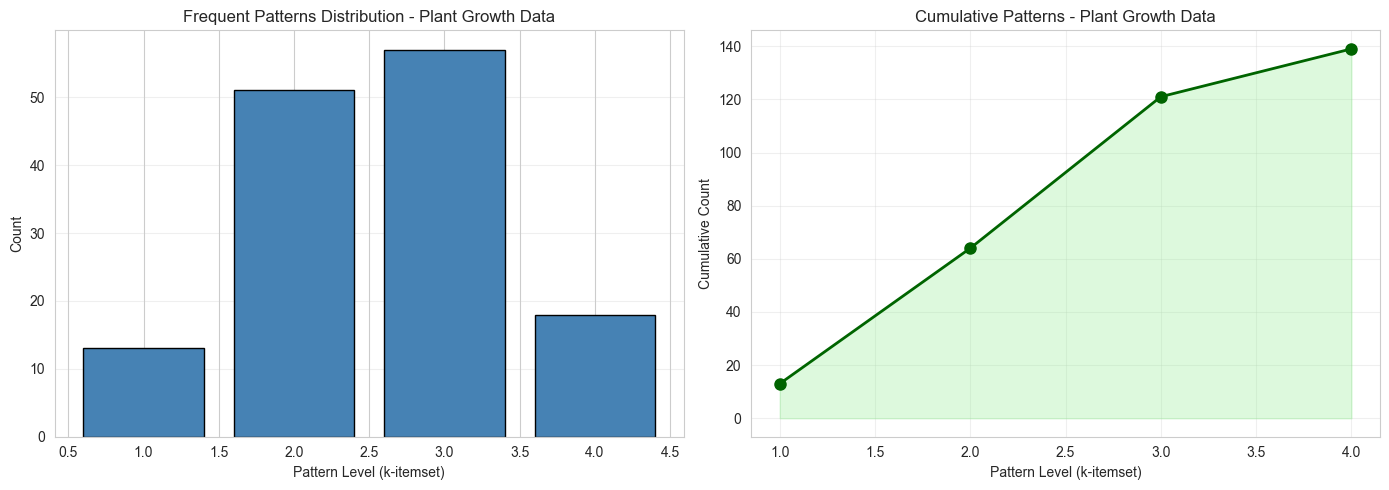


✓ Dataset2 berhasil dianalisis


In [8]:
dataset2_path = r'Dataset\Dataset2_CSV_PlantGrowthDataClassification\plant_growth_data.csv'

if os.path.exists(dataset2_path):
    model_plant, data_plant = run_aprioritid_analysis(dataset2_path, "Plant Growth Data", "Growth_Milestone")
    print(f"\n✓ Dataset2 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset2_path}")

## Cell 4: Dataset3 - Agriculture & Farming (Yield Prediction)


APRIORITID ANALYSIS: Agriculture & Farming (Yield Padi)

📊 Data Shape: (50, 10)
Kolom: ['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 0 data outlier
✓ Label Encoding: 5 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: 8 fitur terpilih

✓ Data setelah preprocessing: (50, 9)

🔍 APRIORITID MODEL:
✓ Total Frequent Patterns: 210
Pattern Distribution by Level: {1: 18, 2: 118, 3: 72, 4: 2}


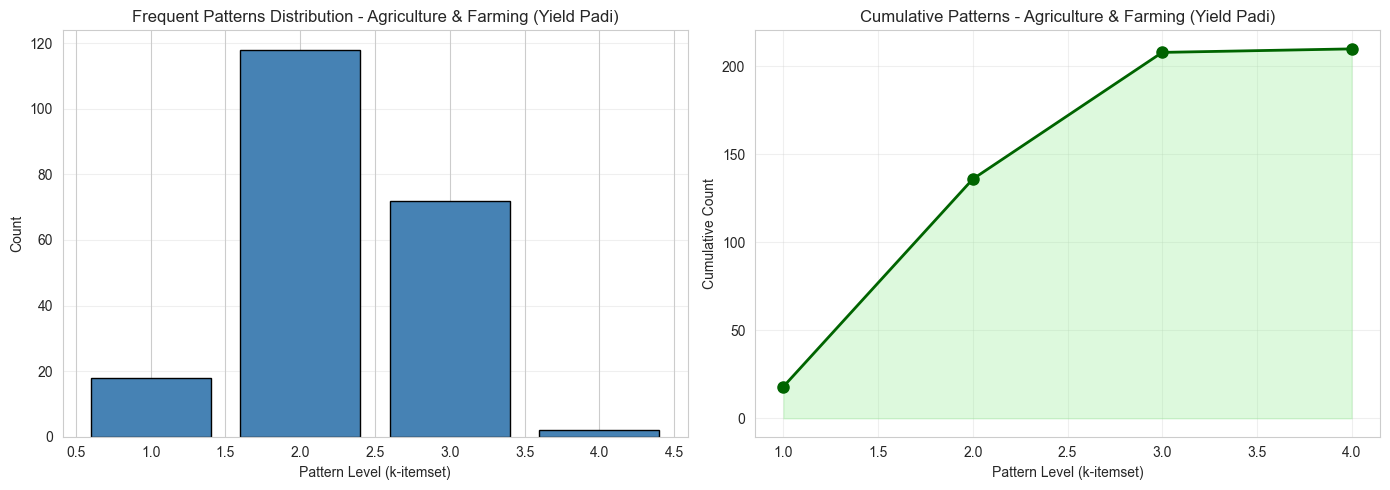


✓ Dataset3 berhasil dianalisis


In [9]:
dataset3_path = r'Dataset\Dataset3_CSV_Agriculture&Farming\agriculture_dataset.csv'

if os.path.exists(dataset3_path):
    model_agri, data_agri = run_aprioritid_analysis(dataset3_path, "Agriculture & Farming (Yield Padi)", "Yield(tons)")
    print(f"\n✓ Dataset3 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset3_path}")

## Cell 5: Model Comparison Summary

In [10]:
print("\n" + "="*60)
print("APRIORITID MODEL SUMMARY")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A',
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A'],
    'Total Patterns': [model_plant.get_summary()['total_patterns'] if 'model_plant' in locals() else 0,
                       model_agri.get_summary()['total_patterns'] if 'model_agri' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORITID MODEL SUMMARY

               Dataset Data Shape  Total Patterns
         Plant Growth   (193, 7)             139
Agriculture & Farming    (50, 9)             210


## Cell 6: Dataset4 - Agricultural Heritage (Seshat Dataset)

In [11]:
# Dataset 4: Agricultural Heritage - Seshat AgriSeshat Dataset
dataset4_path = r'Dataset\Dataset4_CSV_AgriSeshatAgricultureDataset\Agriculture.csv'

if os.path.exists(dataset4_path):
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"APRIORUTID ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n📊 Data Shape: {df_seshat.shape}")
    
    # Preprocessing khusus
    categorical_cols = ['NGA', 'Variable', 'Value From', 'Value To', 'Unit']
    existing_cols = [col for col in categorical_cols if col in df_seshat.columns]
    df_seshat_processed = df_seshat[existing_cols].copy()
    
    for col in df_seshat_processed.columns:
        df_seshat_processed[col].fillna(df_seshat_processed[col].mode()[0] if len(df_seshat_processed[col].mode()) > 0 else 'Unknown', inplace=True)
    
    print(f"✓ Handle Missing Values: Selesai")
    
    le_dict = {}
    for col in df_seshat_processed.columns:
        le = LabelEncoder()
        df_seshat_processed[col] = le.fit_transform(df_seshat_processed[col].astype(str))
        le_dict[col] = le
    
    print(f"✓ Label Encoding: {len(df_seshat_processed.columns)} fitur di-encode")
    
    print("\n🔍 APRIORUTID MODEL (Dataset4):")
    model_seshat = AprioriTidModel(min_support=0.1)
    model_seshat.fit(df_seshat_processed)
    
    summary_seshat = model_seshat.get_summary()
    print(f"✓ Total Patterns: {summary_seshat['total_patterns']}")
    print(f"✓ Patterns by Level: {summary_seshat['patterns_by_level']}")
    
    print(f"\n✓ Dataset4 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset4_path}")


APRIORUTID ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
✓ Handle Missing Values: Selesai
✓ Label Encoding: 5 fitur di-encode

🔍 APRIORUTID MODEL (Dataset4):
✓ Total Patterns: 109
✓ Patterns by Level: {1: 9, 2: 29, 3: 40, 4: 25, 5: 6}

✓ Dataset4 berhasil dianalisis


## Cell 7: Updated Summary - All Datasets

In [12]:
# Final summary with all datasets
print("\n" + "="*60)
print("APRIORUTID MODEL SUMMARY - ALL DATASETS")
print("="*60)

summary_data = {
    'Dataset': ['Rice Leaf Diseases', 'Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_rice.shape) if 'data_rice' in locals() else 'N/A',
                   str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Total Patterns': [model_rice.get_summary()['total_patterns'] if 'model_rice' in locals() else 0,
                       model_plant.get_summary()['total_patterns'] if 'model_plant' in locals() else 0,
                       model_agri.get_summary()['total_patterns'] if 'model_agri' in locals() else 0,
                       model_seshat.get_summary()['total_patterns'] if 'model_seshat' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORUTID MODEL SUMMARY - ALL DATASETS

               Dataset Data Shape  Total Patterns
   Rice Leaf Diseases    (90, 6)             113
         Plant Growth   (193, 7)             139
Agriculture & Farming    (50, 9)             210
Agricultural Heritage   (330, 5)             109
